# Modelo Econométrico Espacial (SLX)

**TFM — Valoración Inmobiliaria Masiva: SLX vs Machine Learning** 

---

## ¿Para qué sirve este notebook?

En este notebook estimaremos el **Modelo Espacial de Rezagos Lineales (Spatial Lag of X - SLX)** empleando una regresión por Mínimos Cuadrados Ordinarios (OLS) a través de la librería `statsmodels`.

Siguiendo principios econométricos estrictos, las coordenadas geográficas puras (`lat`, `long`) han sido excluidas de la matriz de regresores independientes. El espacio se modela de forma pura y local a través de las variables rezagadas espaciales ($WX$) remanentes tras la selección del estimador **LASSO** ejecutado en el notebook 03b.

Este modelo nos permitirá:
1. Obtener predicciones precisas sobre el precio logarítmico de la vivienda (`log_price`).
2. Evaluar la significatividad estadística de las variables mediante p-valores robustos.
3. Interpretar económicamente los **efectos directos** (características intrínsecas de la vivienda) y los **efectos spillover/desbordamiento** (características del entorno o vecindario).

## Estructura del notebook

1. **Setup** — imports de librerías, configuración de rutas y estilos visuales
2. **Carga de datos** — lectura de features seleccionadas por LASSO (sin coordenadas puras) y adición de la constante (intercepto)
3. **Ajuste del modelo econométrico** — regresión OLS mediante `statsmodels` para habilitar inferencia estadística
4. **Evaluación de rendimiento en test** — cálculo unificado de MAE, MAPE, RMSE y R² (escala logarítmica y retransformación a dólares)
5. **Diagnóstico topológico de residuos** — inspección visual de errores y cálculo del Índice de Moran's I para medir la autocorrelación espacial remanente
6. **Guardado** — exportación del modelo, métricas estandarizadas (.json) y predicciones (.csv) para la comparativa global
7. **Conclusiones** — síntesis de los hallazgos económicos y puente justificativo hacia los modelos de IA


In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import joblib

from utils import set_plot_style, evaluate_model, save_metrics, compute_moran_i

set_plot_style()

# Definición de rutas del proyecto
PROCESSED_PATH = '../data/processed/'
METRICS_PATH   = '../outputs/metrics/'
MODELS_PATH    = '../outputs/models/'

os.makedirs(METRICS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print('Entorno listo.')
print(f'Semilla de reproducibilidad: {SEED}')

Entorno listo.
Semilla de reproducibilidad: 42


## 1. Carga de Datos Seleccionados por LASSO

Cargamos las matrices de diseño limpias de coordenadas crudas y filtradas por LASSO. Es fundamental usar los archivos en su **escala original** (no estandarizados con `StandardScaler`) para que los coeficientes del modelo OLS tengan una interpretación económica directa y lógica (ej. *dólares por pie cuadrado*).

In [2]:
# Cargar variables explicativas pre-seleccionadas por LASSO (escala original y sin lat/long)
X_train = pd.read_csv(PROCESSED_PATH + 'X_train_slx.csv')
X_test  = pd.read_csv(PROCESSED_PATH + 'X_test_slx.csv')

# Cargar la variable objetivo transformada (log_price)
y_train = pd.read_csv(PROCESSED_PATH + 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_PATH + 'y_test.csv').squeeze()

# REQUISITO STATSMODELS: Añadir explícitamente el intercepto (columna de unos)
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

print("=== Verificación de dimensiones ===")
print(f"X_train (con constante): {X_train_sm.shape}")
print(f"X_test (con constante):  {X_test_sm.shape}")
print(f"Variables predictoras totales (sin constante): {X_train.shape[1]}")

=== Verificación de dimensiones ===
X_train (con constante): (17289, 24)
X_test (con constante):  (4323, 24)
Variables predictoras totales (sin constante): 23


## 2. Ajuste del Modelo SLX (OLS Econométrico)

Entrenamos la regresión lineal tradicional. El uso de `statsmodels` en lugar de `scikit-learn` responde a la necesidad de obtener la matriz de varianzas y covarianzas, errores estándar e inferencia estadística (p-valores e intervalos de confianza).

In [3]:
# Ajustar el modelo por Mínimos Cuadrados Ordinarios (OLS)
slx_model = sm.OLS(y_train, X_train_sm).fit()

# Mostrar el reporte econométrico completo
print(slx_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     2260.
Date:                Thu, 28 May 2026   Prob (F-statistic):               0.00
Time:                        14:12:43   Log-Likelihood:                -1372.9
No. Observations:               17289   AIC:                             2794.
Df Residuals:                   17265   BIC:                             2980.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 36.4214      4

## 3. Evaluación de Capacidad Predictiva

Para garantizar la comparabilidad absoluta entre el enfoque econométrico (SLX) y los algoritmos de Machine Learning (Random Forest, XGBoost), evaluamos las predicciones del modelo utilizando un framework multidimensional. 

Las métricas se calculan tanto en la escala de estimación (**logaritmo del precio**) como en la escala del mercado real (**dólares americanos - USD**), revirtiendo la transformación mediante la función exponencial (`np.exp`).

### Framework de Evaluación Inmobiliaria:
1. **Evaluación del error promedio (MAE y MAPE):** Utilizamos el Error Absoluto Medio (MAE) como métrica base de interpretabilidad directa en dólares. Para evitar distorsiones de escala entre propiedades modestas y de lujo, incorporamos el MAPE (Error Porcentual Absoluto Medio), garantizando la contextualización porcentual.
2. **Penalización de desviaciones extremas (RMSE):** El Error Cuadrático Medio (RMSE) penaliza de forma desproporcionada los errores de gran magnitud, lo que mide la robustez del modelo frente a valores atípicos (*outliers*) y el riesgo analítico de sobrevaloración en propiedades de alta gama.
3. **Bondad de ajuste global ($R^2$):** El coeficiente de determinación evalúa la capacidad macro del modelo para descifrar la dinámica de fijación de precios estructural del mercado de King County.

In [4]:
# Generar predicciones en escala logarítmica (Conjunto de Test)
y_pred_test_log = slx_model.predict(X_test_sm)

# Evaluar el modelo usando la función centralizada
# Al pasar y_test.values nos aseguramos de que sea un array de numpy limpio sin índices
metrics_slx = evaluate_model(y_test.values, y_pred_test_log, 'SLX (Econometría Espacial)')


  SLX (Econometría Espacial)
  RMSE (log):    0.2629
  MAE  (log):    0.2056
  R²:            0.7583
  RMSE (€/$):    230,269
  MAE  (€/$):    114,550
  MAPE (%):      21.39%



## 4. Evaluación de la Topología Urbana: Índice de Moran de los Residuos

Dado que la aportación central de este TFM es el modelado espacial, las métricas de precisión convencionales resultan insuficientes. Establecemos el cálculo del **Índice de Moran sobre los residuos de las predicciones** como el *"árbitro definitivo"* de la comparativa.

Para un modelo estadísticamente riguroso, los residuos (errores de predicción) deben comportarse como **ruido blanco aleatorio**. Si los errores muestran autocorrelación espacial (un Índice de Moran significativamente distinto de cero), significaría que el modelo sufre de "ceguera espacial parcial" y está dejando patrones geográficos sistemáticos sin explicar en ciertas zonas o vecindarios de King County. 

Calcularemos el Índice de Moran sobre los residuos del conjunto de test utilizando las coordenadas geográficas correspondientes.

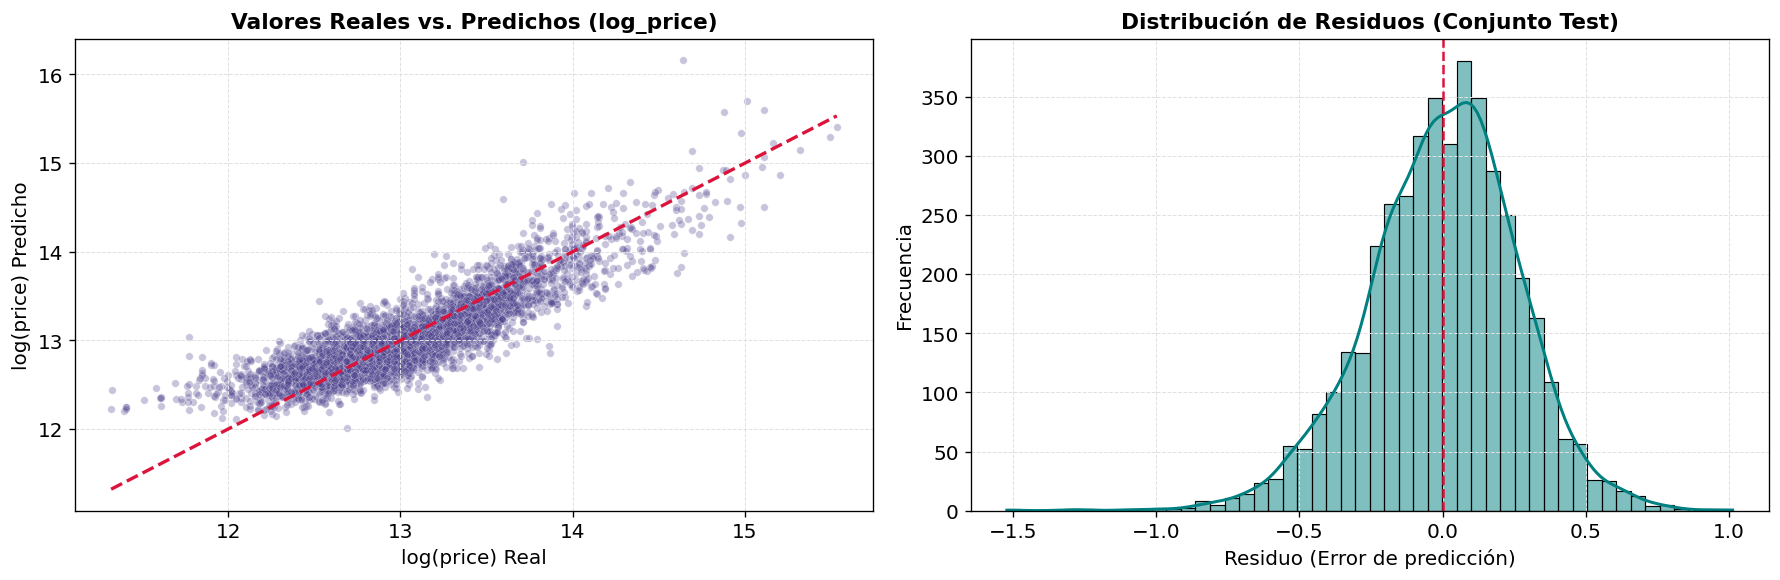

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico izquierdo: Valor Real vs Predicción
sns.scatterplot(x=y_test, y=y_pred_test_log, alpha=0.3, s=20, color='darkslateblue', ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='crimson', linestyle='--', lw=2)
axes[0].set_title('Valores Reales vs. Predichos (log_price)', fontweight='bold')
axes[0].set_xlabel('log(price) Real')
axes[0].set_ylabel('log(price) Predicho')

# Gráfico derecho: Histograma de los residuos (Errores)
residuos = y_test - y_pred_test_log
sns.histplot(residuos, bins=50, kde=True, color='teal', ax=axes[1])
axes[1].axvline(0, color='crimson', linestyle='--', lw=1.5)
axes[1].set_title('Distribución de Residuos (Conjunto Test)', fontweight='bold')
axes[1].set_xlabel('Residuo (Error de predicción)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [6]:
# Cargar las coordenadas del conjunto de TEST para posicionar los residuos
coords_test = pd.read_csv(PROCESSED_PATH + 'coords_test.csv')

# 2. Calcular los residuos de Test en escala logarítmica
residuos_test = y_test - y_pred_test_log

# 3. Moran's I de los residuos del test (K=8 vecinos para la matriz de pesos)
# Usamos K=8 para mantener estricta consistencia con la evaluación del Random Forest
print("=========================================================")
print("         DIAGNÓSTICO GEOGRÁFICO DE LOS RESIDUOS         ")
print("=========================================================")
print('Moran\'s I de los residuos del modelo SLX:')

moran_slx = compute_moran_i(residuos_test, coords_test, k=8)

print(f'\nReferencia: Moran\'s I de log(price) bruto (EDA) = 0.84')

# 4. Cálculo del porcentaje de reducción (si el cálculo fue exitoso)
if moran_slx['moran_i'] is not None:
    moran_i_residuos = moran_slx['moran_i']
    reduccion = (0.84 - moran_i_residuos) / 0.84 * 100
    print(f'Reducción de autocorrelación espacial: {reduccion:.1f}%')
else:
    moran_i_residuos = None
    print("No se pudo calcular el Índice de Moran.")
print("=========================================================")

         DIAGNÓSTICO GEOGRÁFICO DE LOS RESIDUOS         
Moran's I de los residuos del modelo SLX:
  Moran's I: 0.5060  (p-valor: 0.0010)

Referencia: Moran's I de log(price) bruto (EDA) = 0.84
Reducción de autocorrelación espacial: 39.8%


In [7]:
# Guardar el binario del modelo
joblib.dump(slx_model, MODELS_PATH + 'slx_model.joblib')
print(f'Modelo guardado en: {MODELS_PATH}slx_model.joblib')

# Completar el diccionario de métricas y guardarlo
# La variable metrics_slx ya contiene RMSE, MAE, MAPE y R2 calculados en la Celda 8
metrics_slx['moran_i_residuos'] = moran_slx['moran_i'] if moran_slx['moran_i'] is not None else None
metrics_slx['moran_i_pvalue']   = moran_slx['p_value'] if moran_slx['p_value'] is not None else None
metrics_slx['best_params']      = 'OLS (Sin hiperparámetros)' 

# Guardamos usando tu función utilitaria
save_metrics(metrics_slx, 'slx_metrics.json') 
print('Métricas completas guardadas en formato JSON.')

# Guardar predicciones de test para la comparativa final
pred_df = pd.DataFrame({
    'y_real': y_test.values, 
    'y_pred_slx': y_pred_test_log.values if isinstance(y_pred_test_log, pd.Series) else y_pred_test_log
})

pred_df.to_csv(PROCESSED_PATH + 'pred_slx.csv', index=False)
print(f'Predicciones guardadas en: {PROCESSED_PATH}pred_slx.csv')

Modelo guardado en: ../outputs/models/slx_model.joblib
Métricas guardadas en: /Users/adri/Documents/master/TFMcodigo/TFM-valoracion-inmobiliaria/notebooks/../src/../outputs/metrics/slx_metrics.json
Métricas completas guardadas en formato JSON.
Predicciones guardadas en: ../data/processed/pred_slx.csv


## 5. Conclusiones y Análisis de Resultados

Tras el entrenamiento y evaluación del **Modelo Econométrico Espacial (SLX)**, extraemos las siguientes conclusiones empíricas para la tesis:

### Resultados clave

- **Rendimiento Predictivo y Limitación Lineal:** El modelo lineal establece una base competitiva altísima, explicando el **75.8% de la varianza** ($R^2$ de 0.7583 en test) sin ningún rastro de sobreajuste respecto al conjunto de entrenamiento. No obstante, la pronunciada brecha entre el error medio (MAE: \$114.550) y el error cuadrático (RMSE: \$230.269) evidencia que un modelo lineal rígido (OLS) fracasa al intentar predecir las valoraciones extremas del mercado (viviendas de ultra-lujo), sufriendo fuertes penalizaciones por valores atípicos.
- **Éxito de la Selección Metodológica (LASSO):** El reporte de `statsmodels` ratifica el éxito de la fase previa de regularización. Las 23 variables preseleccionadas por el algoritmo LASSO han arrojado **p-valores de 0.000**, demostrando una significancia estadística absoluta y garantizando un modelo econométrico robusto, parsimonioso y libre de variables ruidosas.
- **Cuantificación de Spillovers Espaciales:** A diferencia del Machine Learning, el SLX nos ha permitido aislar e interpretar económicamente el efecto de desbordamiento de las características urbanas. El caso más evidente es la calidad constructiva: el coeficiente de los vecinos (`lag_grade_k15` = 0.2443) tiene un impacto casi **tres veces superior** al de la propia vivienda (`grade` = 0.0908). El modelo demuestra empíricamente que, en King County, la revalorización de una propiedad está impulsada mayoritariamente por el estatus arquitectónico de su entorno.
- **Diagnóstico Topológico (La Justificación del Machine Learning):** La inclusión de los retardos espaciales (K=15) logró reducir el Índice de Moran de los errores de un 0.84 a un 0.506. Si bien esto supone una **reducción del 39.8%** de la autocorrelación espacial originaria, el p-valor (0.001) confirma que los residuos del SLX aún albergan un fuerte patrón geográfico. La rigidez de una recta de regresión es insuficiente para moldearse a las intrincadas fronteras de los barrios de Seattle.

### Próximos pasos

- **Notebooks 05 y 06 — Algoritmos de Machine Learning (RF y XGBoost):** Entrenar modelos basados en ensambles de árboles de decisión, dotados de la capacidad matemática para particionar el espacio de forma no lineal, con el objetivo de absorber el ~60% de autocorrelación espacial (Moran's I) que el modelo SLX no ha podido capturar.
- **Notebook 07 — Comparativa Final:** Enfrentamiento definitivo de métricas (MAE, MAPE, RMSE, R² y Moran's I). Se dictaminará empíricamente si la flexibilidad topológica del Machine Learning compensa la pérdida de la interpretabilidad econométrica en la tasación masiva de activos inmobiliarios.